In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import seaborn as sns
import cloudpickle

from sc_exp_design.models import FlowMatchingWithScore

NeuralVelocityFieldWithScore(
  (vf_modules): ModuleDict(
    (x_encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=12, out_features=256, bias=True)
          (1): ELU(alpha=1.0)
        )
        (1): Sequential(
          (0): Linear(in_features=256, out_features=16, bias=True)
          (1): Identity()
        )
      )
    )
    (time_encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=256, out_features=256, bias=True)
          (1): ELU(alpha=1.0)
        )
        (1): Sequential(
          (0): Linear(in_features=256, out_features=8, bias=True)
          (1): Identity()
        )
      )
    )
    (resnet_blocks): ModuleList(
      (0-2): 3 x ResnetBlock(
        (net1): Sequential(
          (0): SiLU()
          (1): Linear(in_features=16, out_features=16, bias=True)
        )
        (cond_proj): Sequential(
          (0): SiLU()
          (1): Linear(in_features=8, out_fe

(<Figure size 300x300 with 1 Axes>, <Axes: title={'center': 'loss'}>)

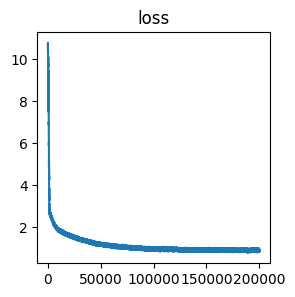

In [2]:
model_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/checkpoints/prior/flow_matching/2026-04-04_10-19-42/woven-dawn-22_FlowMatchingWithScore.pkl"
model = FlowMatchingWithScore.load(model_path)
print(model.velocity_field)
model.trainer.plot_training_logs()

In [3]:
n_train_samples_to_retain = 100_000
train_adata = model.train_data.adata
train_adata_subset = sc.pp.sample(train_adata, n=n_train_samples_to_retain, copy=True)
train_adata_subset

AnnData object with n_obs × n_vars = 100000 × 12

In [4]:
num_prior_samples = 150
num_time_steps = 500
solver_kwargs = {"method":"euler"}
prior_samples = model.predict(
    {},
    batch_size=num_prior_samples,
    num_time_steps=num_time_steps,
    solver_kwargs=solver_kwargs,
).detach().cpu().numpy()
prior_samples = np.maximum(prior_samples, 0)
print(prior_samples.shape)

(150, 12)


<Axes: >

<Figure size 750x750 with 0 Axes>

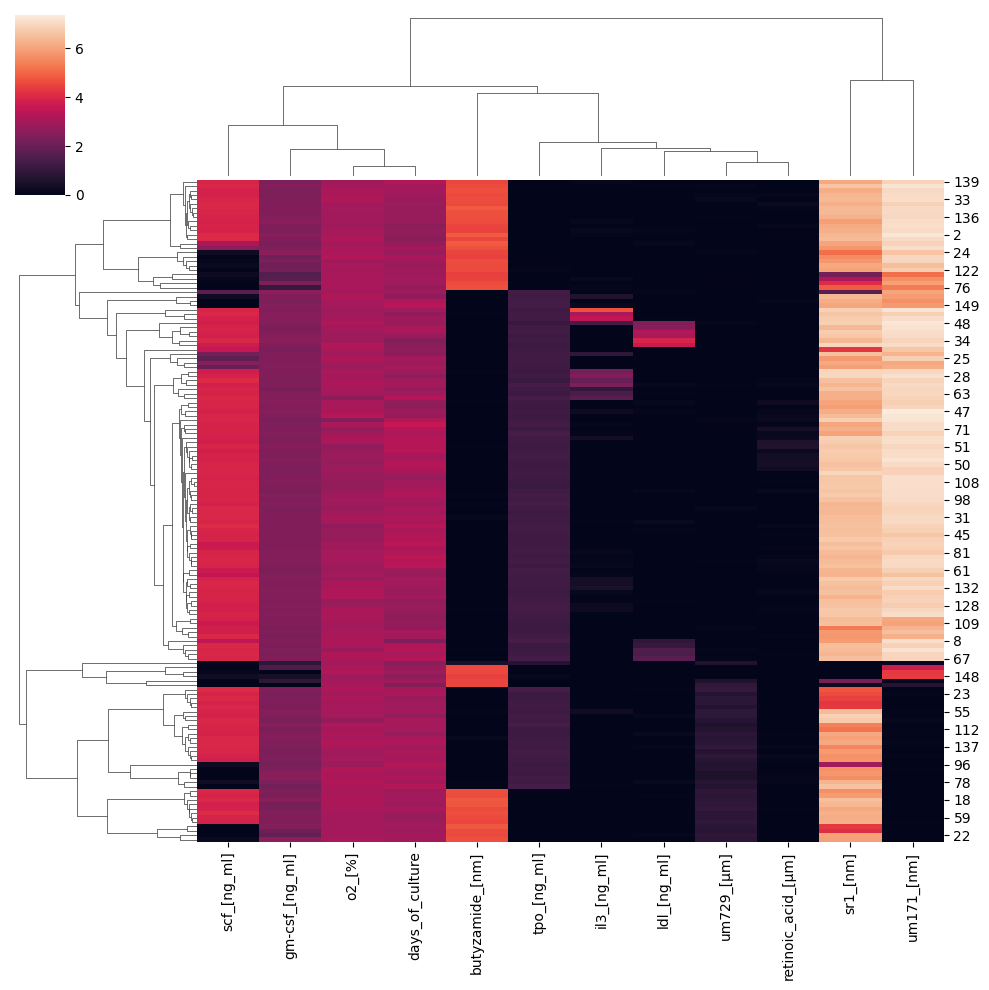

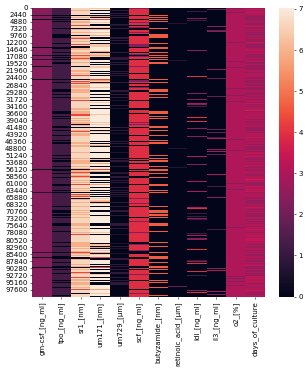

In [5]:
# fig, ax = plt.subplots(1, 1, figsize=(15, 7.5), dpi=100)
# fig, ax = plt.subplots(1, 1, figsize=(15, 7.5), dpi=100)
# fig.suptitle("Heatmap of condition samples")
plt.figure(figsize=(7.5, 7.5), dpi=100)
# plt.title("Heatmap of condition samples")
sns.clustermap(
    prior_samples,
    annot=False,
    xticklabels=train_adata.var_names,
    # ax=ax[0]
)#; ax[0].tick_params("x", rotation=90, size=4); ax[0].set_title("Prior Samples."); ax[0].set_yticks([])
# plt.title("Heatmap of condition samples")

# ax[0].set_xlabel("Molecule"); ax[0].set_ylabel("Samples")
plt.figure(figsize=(7.5, 7.5), dpi=50)
sns.heatmap(
    train_adata_subset.X,
    annot=False,
    xticklabels=train_adata.var_names,
    # ax=ax[1]
)#; ax[1].tick_params("x", rotation=90, size=4); ax[1].set_title("Subsampled data."); ax[1].set_yticks([])
# ax[1].set_xlabel("Molecule"); ax[1].set_ylabel("Samples")
# fig.tight_layout(); fig.show()

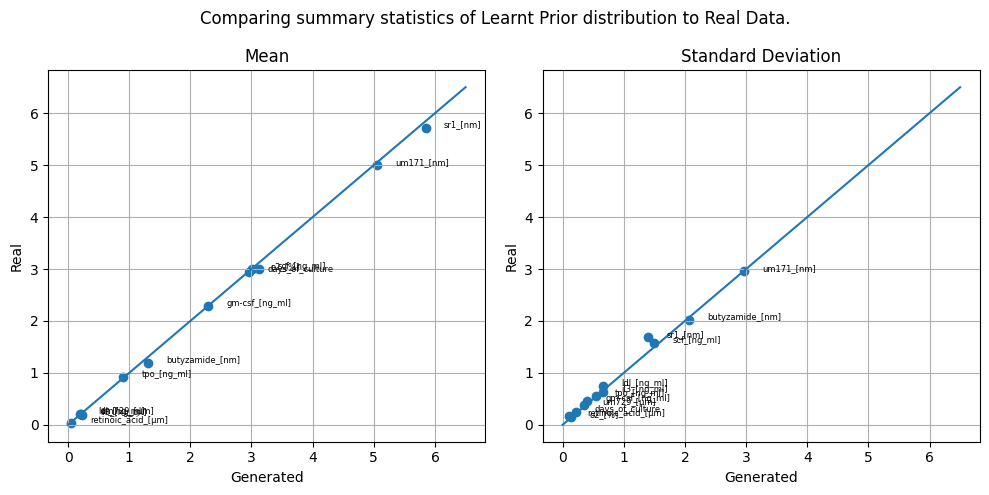

In [6]:
# mean
prior_mean = prior_samples.mean(0)
real_mean = train_adata_subset.X.mean(0)

# standard deviation
prior_std = prior_samples.std(0)
real_std = train_adata_subset.X.std(0)

# initializing plot
fig, ax = plt.subplots(1, 2, figsize=(10, 5), dpi=100)
fig.suptitle("Comparing summary statistics of Learnt Prior distribution to Real Data.")

# contructing linear space
linspace = np.linspace(0.0, 6.5, 100)

# plotting mean
ax[0].scatter(prior_mean, real_mean); ax[0].grid(True)
ax[0].set_title("Mean"); ax[0].set_xlabel("Generated"); ax[0].set_ylabel("Real")
ax[0].plot(linspace, linspace)
yoffset = 0.0
xoffset = 0.3
for i, txt in enumerate(train_adata.var_names):
    ax[0].annotate(txt, (prior_mean[i] + xoffset, real_mean[i] + yoffset), size=6)

# plotting standard deviation
ax[1].scatter(prior_std, real_std); ax[1].grid(True)
ax[1].set_title("Standard Deviation"); ax[1].set_xlabel("Generated"); ax[1].set_ylabel("Real")
for i, txt in enumerate(train_adata.var_names):
    ax[1].annotate(txt, (prior_std[i] + xoffset, real_std[i] + yoffset), size=6)
ax[1].plot(linspace, linspace)

fig.tight_layout(); fig.show()